In [1]:
import matplotlib.pyplot as plt
import numpy as np

GenerationReport(requested=10, generated=10, failed=0, total_attempts=20, failure_reasons={'shape_placement_failed': 10}, parameter_ranges={}, metadata={})
10


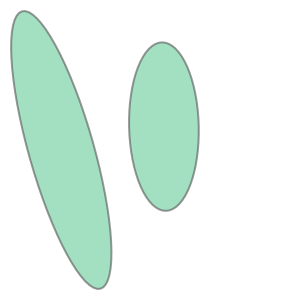

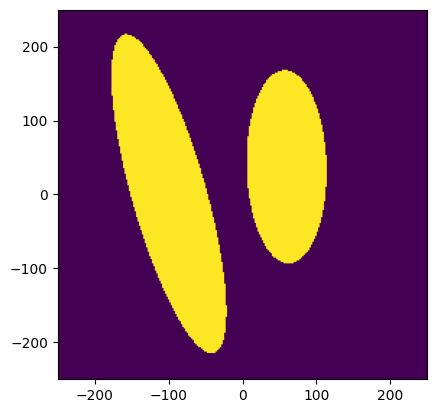

In [21]:
from metashapes.generators.random import RandomGeneratorConfig, RandomUnitCellGenerator
from metashapes.generators.validator import DefaultUnitCellValidator
from metashapes.canvas import Canvas

cfg = RandomGeneratorConfig(
    target_count=10,
    fixed_num_shapes=2,
    allowed_shapes=("Rectangle", "Ellipse"),
    shape_weights={
        "Rectangle": 0.3,
        "Ellipse": 1.0,
    },
    min_shape_size=100,
    min_feature_size=50,
    min_gap=50,
    seed=40,
    max_tries_per_cell=100,
    max_tries_per_shape=100,
    fixed_shape_params={
        "Rectangle": {
            #"center": (0, 0),
            #"axes": (450, 450),
            'corner_radius': 10,
        
        }},
    shape_param_ranges={
        "Rectangle": {
            #"size": ((200, 250), (100, 150)),
            #"angle": (5, 10),
        }},
)

canvas = Canvas(Lx=500, Ly=500, W=256, H=256)

gen = RandomUnitCellGenerator(cfg, validator=DefaultUnitCellValidator())
result = gen.generate(canvas)

print(result.report)
print(len(result.unit_cells))

plt.imshow(result.unit_cells[2].mask_numpy(), origin='lower', extent=(-canvas.Lx/2, canvas.Lx/2, -canvas.Ly/2, canvas.Ly/2))
result.unit_cells[2].to_shapely()

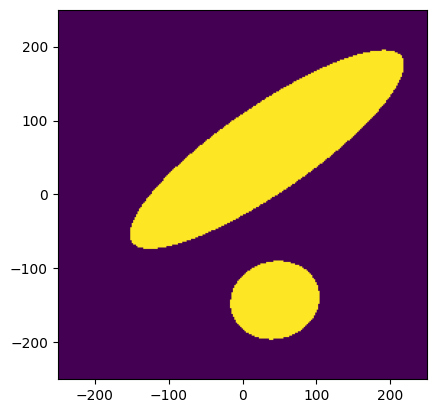

In [20]:
plt.imshow(result.unit_cells[5].mask_numpy(), origin='lower', extent=(-canvas.Lx/2, canvas.Lx/2, -canvas.Ly/2, canvas.Ly/2))